# 06 Short-circuit current

*APPLY*

**Question:** What current flows for one declared fault?

- Declare IEEE 13-node bus 675, phase A, and `0.001 Ω` fault resistance.
- Inspect solver-returned current and verify the exact run.
- Fault current does not establish relay, breaker, arc-flash, or protection acceptance.

## ⚙ Setup — Initialize the teaching environment

Run the setup cell once to load helpers and check runtime dependencies.

In [1]:
#@title 1. Setup — run once
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "7707385fd5fe60a9bec2e0bdd1bda33bc7b06bab71a8304dff0a7de86d23a0c6":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0


Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## 🧩 Inputs — Declare the fault scenario

Set bus 675, phase A, and fault resistance \(R_f=0.001\ \Omega\).

In [2]:
#@title 2. Inputs — fault location and impedance
RUN_DIR = WORKSPACE / "runs" / "04-fault-study"
FAULT_BUS = "675"
FAULT_PHASE = 1
FAULT_RESISTANCE_OHM = 0.001
table(
    ["declared input", "value", "unit"],
    [
        ("network", "IEEE 13-node feeder", "text"),
        ("fault bus", FAULT_BUS, "bus"),
        ("fault phase", "A", "phase"),
        ("fault resistance", FAULT_RESISTANCE_OHM, "ohm"),
    ],
)

declared input    value                unit
----------------  -------------------  -----
network           IEEE 13-node feeder  text
fault bus         675                  bus
fault phase       A                    phase
fault resistance  0.001                ohm


## ▶ Run — Solve the fault study

Run `cept run --demo fault --network ieee13`; CEPT solves the declared event through OpenDSS.


In [3]:
# 3. Run study — same CEPT CLI as a normal terminal
!cept run --demo fault \
    --network ieee13 \
    --out runs/04-fault-study \
    --force \
    --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the fault study and saved the evidence
Saved run          runs\04-fault-study
Case fingerprint   44d3766e5e8c (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept verify runs\04-fault-study --format text


## 🔎 Explore — Locate the fault on the feeder

View the SLD and trace current paths from bus 675 to the source.


In [4]:
#@title 4. Explore — SLD and bus status
RUN_DIR = WORKSPACE / "runs" / "04-fault-study"
display_sld(RUN_DIR)

Bus,Phase A,Phase B,Phase C,Status
611,—,—,1.2235 pu @ 132.01°,OVER
632,0.5915 pu @ -2.77°,1.1656 pu @ -131.51°,1.1292 pu @ 126.18°,OUT
633,0.5904 pu @ -2.79°,1.1627 pu @ -131.54°,1.1267 pu @ 126.13°,OUT
634,0.5763 pu @ -3.48°,1.1432 pu @ -131.97°,1.1078 pu @ 125.70°,OUT
645,—,1.1562 pu @ -131.70°,1.1272 pu @ 126.21°,OVER
646,—,1.1547 pu @ -131.78°,1.1253 pu @ 126.26°,OVER
650,0.9988 pu @ -0.02°,0.9998 pu @ -119.99°,0.9998 pu @ 119.97°,OK
652,0.1054 pu @ -37.66°,—,—,UNDER
670,0.4243 pu @ -5.48°,1.2218 pu @ -134.46°,1.1593 pu @ 128.24°,OUT
671,0.1058 pu @ -38.18°,1.3467 pu @ -139.55°,1.2279 pu @ 132.28°,OUT


## 📊 Results — Read the fault current

Read total current and phase contributions from `results.json` for the declared event.


In [5]:
#@title 5. Engineering result — fault current
results = read(RUN_DIR / "results.json")
fault = results["fault"]
table(
    ["quantity", "value", "unit"],
    [
        ("fault bus", fault["bus"], "bus"),
        ("fault type", fault["fault_type"], "text"),
        ("fault resistance", fault["rf_ohm"], "ohm"),
        ("fault phases", fault["phases"], "phase"),
        ("total fault current", fault["total_fault_current_a"], "A"),
    ],
)
assert fault["bus"].lower() == FAULT_BUS.lower()
assert fault["phases"] == [FAULT_PHASE]

quantity             value   unit
-------------------  ------  -----
fault bus            675     bus
fault type           slg     text
fault resistance     0.001   ohm
fault phases         [1]     phase
total fault current  2950.7  A


## 📈 Plot — Read the fault current by phase

Read the solver-returned current for the declared fault; the optional section later compares it with a direct OpenDSS solve of the same event.

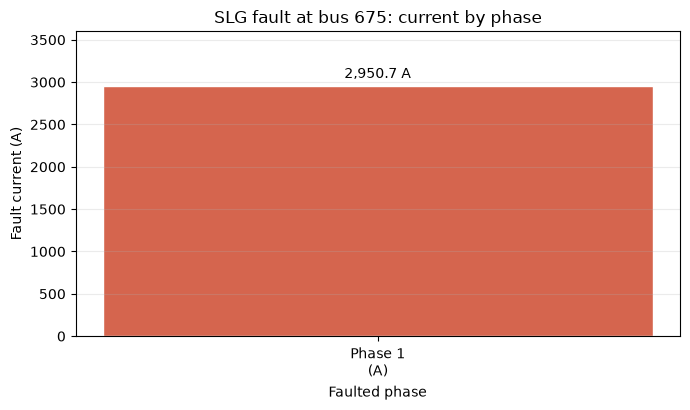

Faulted phase current: 2,950.7 A for the declared event.


In [6]:
#@title 6. Plot — fault current by phase
import matplotlib.pyplot as plt

_fault = read(WORKSPACE / "runs" / "04-fault-study" / "results.json")["fault"]
_by_phase = {int(row["phase"]): float(row["i_amp"]) for row in _fault["currents"]}
phase_labels = [f"Phase {phase}\n({ {1: 'A', 2: 'B', 3: 'C'}[phase] })" for phase in sorted(_by_phase)]
phase_values = [_by_phase[phase] for phase in sorted(_by_phase)]
cept_current_a = float(_fault["total_fault_current_a"])

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(phase_labels, phase_values, color=["#d5654e", "#1f5b4d", "#e9b95f"][: len(phase_values)],
              edgecolor="white")
for bar, value in zip(bars, phase_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + max(phase_values) * 0.02,
            f"{value:,.1f} A", ha="center", va="bottom", fontsize=10)
ax.set_title(f"SLG fault at bus {_fault['bus']}: current by phase")
ax.set_xlabel("Faulted phase")
ax.set_ylabel("Fault current (A)")
ax.set_ylim(0, max(phase_values) * 1.22)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)
print(f"Faulted phase current: {cept_current_a:,.1f} A for the declared event.")



## ✓ Verify — Check the saved run

Verify this exact run directory and its persisted artifacts.


In [7]:
# 6. Verify — check this exact saved run
!cept verify runs/04-fault-study --format text

CEPT study check: PASSED
----------------------------
Study              Fault study (OpenDSS)
Case fingerprint   44d3766e5e8c (matches the case you ran)

Checked   3 groups, 13 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (2 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept verify . --format json


## ◇ Interpret — Bound the result

- The reported current is scoped to the declared source, feeder, bus, phase, and resistance.
- It does not establish breaker interrupting duty, relay settings, arc-flash results, or protection acceptance.

**Try next:** increase fault resistance in a separate direct-solver calculation and compare the result.

## 🧪 Optional — Compare a direct OpenDSS fault solve

These cells solve the same declared fault directly, then compare its returned current with the persisted CEPT result.

In [8]:
#@title Under the hood - direct OpenDSS fault solve (optional)
MASTER_DSS = ieee13_master()
import opendssdirect as dss

dss.Basic.ClearAll()
dss.Basic.DataPath(str(MASTER_DSS.parent))
dss.Text.Command(f'Redirect "{MASTER_DSS}"')
dss.Text.Command(f'New Fault.lesson_fault Bus1={FAULT_BUS}.{FAULT_PHASE} phases=1 r={FAULT_RESISTANCE_OHM}')
dss.Text.Command('Solve')
assert dss.Solution.Converged()
os.chdir(WORKSPACE)
print("Direct OpenDSS fault solve finished: the faulted feeder converged.")


Direct OpenDSS fault solve finished: the faulted feeder converged.


In [9]:
#@title Under the hood — direct fault readback (optional)
dss.Circuit.SetActiveElement('Fault.lesson_fault')
currents = dss.CktElement.Currents()
direct_current_a = abs(complex(currents[0], currents[1]))
table(['source', 'bus', 'phase', 'fault resistance', 'current', 'units'], [('direct OpenDSS', FAULT_BUS, FAULT_PHASE, FAULT_RESISTANCE_OHM, direct_current_a, 'ohm / A')])
assert direct_current_a > 0

source          bus  phase  fault resistance  current            units
--------------  ---  -----  ----------------  -----------------  -------
direct OpenDSS  675  1      0.001             2950.698148621237  ohm / A


In [10]:
#@title Compare solver outputs (optional details)
RUN_DIR = WORKSPACE / "runs" / "04-fault-study"
results = read(RUN_DIR / "results.json")
verify_summary = read(RUN_DIR / "public-verification.json")
fault = results["fault"]
cept_current_a = float(fault["total_fault_current_a"])
fault_abs_diff_a = abs(direct_current_a - cept_current_a)
table(
    ["source", "total fault current", "unit"],
    [("direct OpenDSS", direct_current_a, "A"), ("CEPT results.json", cept_current_a, "A")],
)
print()
print("Direct OpenDSS and CEPT fault currents agree")
print("-------------------------------------------")
print(f"Result        {'PASSED' if verify_summary['passed'] else 'Needs attention'}")
print(f"Fault current is about {cept_current_a:.1f} A")
print(f"The two solvers differ by {fault_abs_diff_a:.2f} A (limit 1.0 A)")
assert verify_summary["status"] == "PASS"
assert verify_summary["passed"] is True
assert fault["bus"].lower() == FAULT_BUS.lower() and fault["fault_type"] == "slg"
assert fault["phases"] == [FAULT_PHASE]
assert fault_abs_diff_a < 1.0


source             total fault current  unit
-----------------  -------------------  ----
direct OpenDSS     2950.698148621237    A
CEPT results.json  2950.7               A

Direct OpenDSS and CEPT fault currents agree
-------------------------------------------
Result        PASSED
Fault current is about 2950.7 A
The two solvers differ by 0.00 A (limit 1.0 A)
